# Stage 2: Chart Detection with YOLO

This notebook demonstrates chart detection using YOLO models.

In [5]:
import sys
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Add project root
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: d:\elix\chart_analysis_ai_v3


## 1. Load YOLO Model

In [6]:
from ultralytics import YOLO

# Try custom chart model first, fallback to pretrained
model_path = project_root / "yolo26n.pt"
if not model_path.exists():
    model_path = project_root / "yolov8n.pt"
if not model_path.exists():
    model_path = "yolov8n.pt"  # Download from ultralytics

model = YOLO(str(model_path))
print(f"Loaded model: {model_path}")

Loaded model: d:\elix\chart_analysis_ai_v3\yolo26n.pt


## 2. Load Test Image

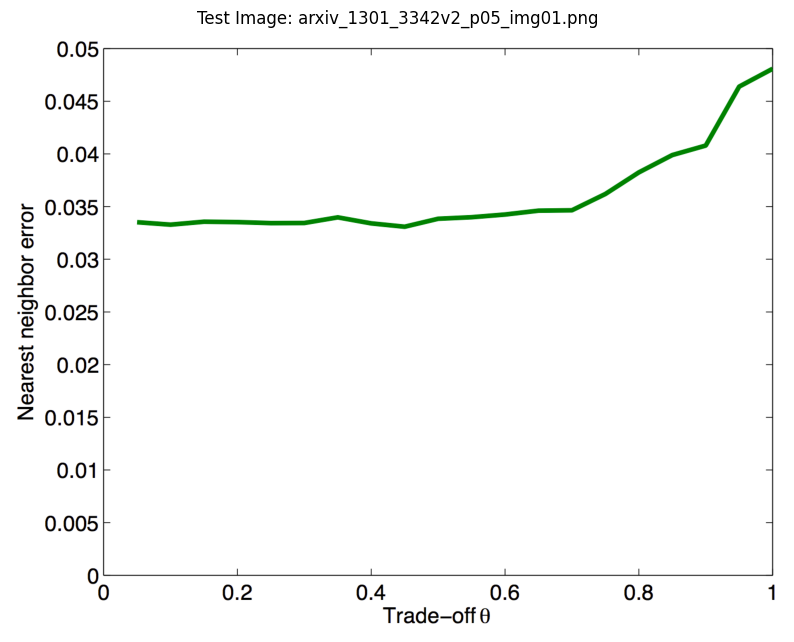

In [10]:
# Find a test image
data_dir = project_root / "data"
image_dirs = [data_dir / "academic_dataset" / "images", data_dir / "samples"]

test_image = None
for d in image_dirs:
    if d.exists():
        images = list(d.glob("*.png")) + list(d.glob("*.jpg"))
        if images:
            test_image = images[0]
            break

if test_image:
    image = cv2.imread(str(test_image))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(image_rgb)
    plt.title(f"Test Image: {test_image.name}")
    plt.axis('off')
    plt.show()
else:
    print("No test images found")

## 3. Run Detection

In [11]:
if test_image:
    results = model.predict(str(test_image), conf=0.25, verbose=False)
    
    print(f"Number of detections: {len(results[0].boxes)}")
    for i, box in enumerate(results[0].boxes):
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        xyxy = box.xyxy[0].cpu().numpy()
        print(f"  [{i}] Class: {model.names[cls_id]}, Conf: {conf:.2f}, Box: {xyxy.astype(int)}")

Number of detections: 0


## 4. Visualize Results

In [12]:
if test_image and len(results[0].boxes) > 0:
    annotated = results[0].plot()
    plt.figure(figsize=(12, 10))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title("Detection Results")
    plt.axis('off')
    plt.show()
else:
    print("No detections to visualize")

No detections to visualize


## 5. Crop Detected Regions

In [ ]:
if test_image and len(results[0].boxes) > 0:
    for i, box in enumerate(results[0].boxes):
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        cropped = image_rgb[y1:y2, x1:x2]
        
        plt.figure(figsize=(8, 6))
        plt.imshow(cropped)
        plt.title(f"Cropped Region {i}")
        plt.axis('off')
        plt.show()
else:
    print("No regions to crop")

## Summary

Stage 2 handles:
- Loading YOLO model (custom or pretrained)
- Running inference on images
- Extracting bounding boxes with confidence scores
- Cropping detected chart regions for Stage 3